In [ ]:
# Install required libraries
!pip install imbalanced-learn xgboost scikit-learn matplotlib seaborn pandas numpy --quiet

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import joblib
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Imbalanced data handling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [ ]:
# -------------------------------------------------------
# STEP 0: Import required libraries
# -------------------------------------------------------
import pandas as pd
import numpy as np

# -------------------------------------------------------
# STEP 1: Mount Google Drive
# -------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

# -------------------------------------------------------
# STEP 2: Specify file path
# Change this path based on where your file is stored
# Example: MyDrive/fraud/creditcard.csv
# -------------------------------------------------------
file_path = '/content/drive/MyDrive/creditcard.csv'

# -------------------------------------------------------
# STEP 3: Load dataset
# -------------------------------------------------------
df = pd.read_csv(file_path)

# -------------------------------------------------------
# STEP 4: Basic checks
# -------------------------------------------------------
print(f'Dataset loaded successfully!')
print(f'Shape: {df.shape}')
print('\nColumns:')
print(df.columns)

print('\nFirst 5 rows:')
display(df.head())

print('\nClass distribution:')
print(df['Class'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!
Shape: (284807, 31)

Columns:
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [ ]:
# ── Basic Info ────────────────────────────────────────────
print('='*60)
print('DATASET OVERVIEW')
print('='*60)
print(f'Shape          : {df.shape}')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplicates     : {df.duplicated().sum()}')
print()
print('Class Distribution:')
fraud_count   = (df['Class'] == 1).sum()
normal_count  = (df['Class'] == 0).sum()
fraud_pct     = fraud_count / len(df) * 100
print(f'  Normal (0): {normal_count:>6,}  ({100-fraud_pct:.2f}%)')
print(f'  Fraud  (1): {fraud_count:>6,}  ({fraud_pct:.4f}%)')
print()
print('Amount Statistics:')
print(df.groupby('Class')['Amount'].describe().round(2))

DATASET OVERVIEW
Shape          : (284807, 31)
Missing values : 0
Duplicates     : 1081

Class Distribution:
  Normal (0): 284,315  (99.83%)
  Fraud  (1):    492  (0.1727%)

Amount Statistics:
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


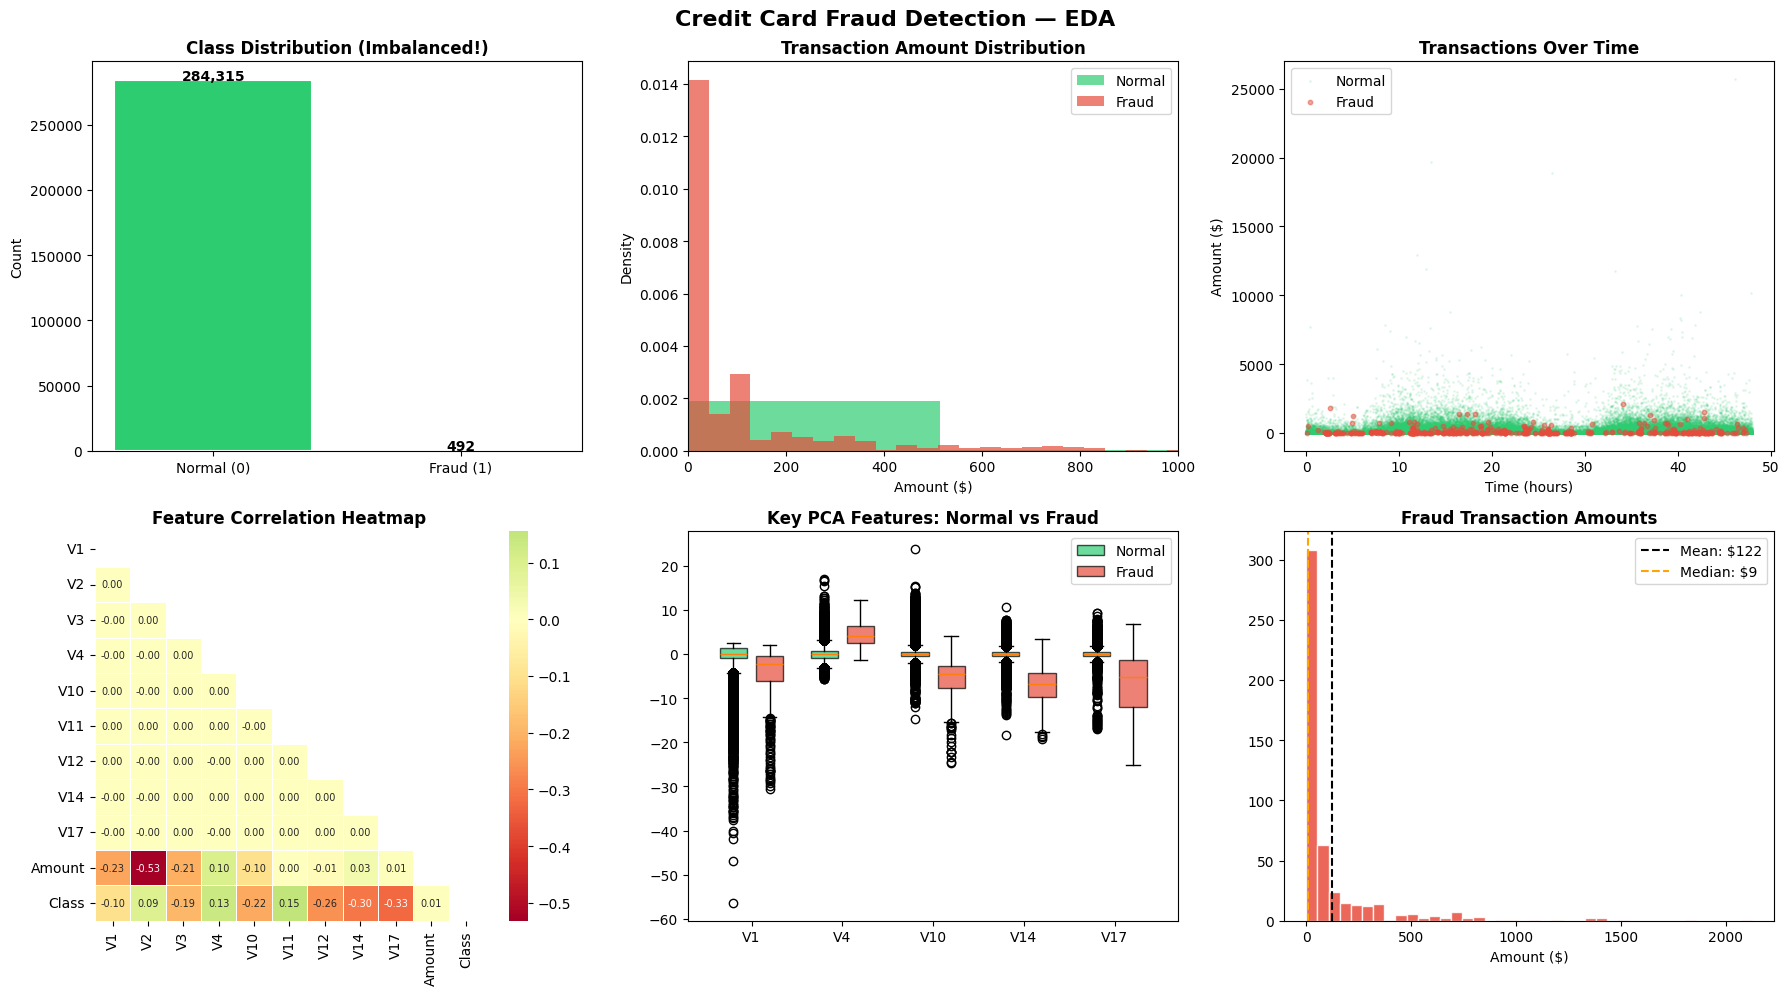

EDA complete!


In [ ]:
# ── Visualization ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Credit Card Fraud Detection — EDA', fontsize=16, fontweight='bold')

# 1. Class imbalance
ax = axes[0, 0]
bars = ax.bar(['Normal (0)', 'Fraud (1)'], [normal_count, fraud_count],
              color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
ax.set_title('Class Distribution (Imbalanced!)', fontweight='bold')
ax.set_ylabel('Count')
for bar, val in zip(bars, [normal_count, fraud_count]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', fontweight='bold')

# 2. Transaction amount: Normal vs Fraud
ax = axes[0, 1]
ax.hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.7, color='#2ecc71', label='Normal', density=True)
ax.hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.7, color='#e74c3c', label='Fraud', density=True)
ax.set_title('Transaction Amount Distribution', fontweight='bold')
ax.set_xlabel('Amount ($)')
ax.set_ylabel('Density')
ax.legend()
ax.set_xlim(0, 1000)

# 3. Time distribution
ax = axes[0, 2]
ax.scatter(df[df['Class']==0]['Time']/3600, df[df['Class']==0]['Amount'],
           alpha=0.1, s=1, color='#2ecc71', label='Normal')
ax.scatter(df[df['Class']==1]['Time']/3600, df[df['Class']==1]['Amount'],
           alpha=0.5, s=10, color='#e74c3c', label='Fraud')
ax.set_title('Transactions Over Time', fontweight='bold')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Amount ($)')
ax.legend()

# 4. Correlation heatmap (top features)
ax = axes[1, 0]
top_features = ['V1','V2','V3','V4','V10','V11','V12','V14','V17','Amount','Class']
corr = df[top_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='RdYlGn', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            square=True, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap', fontweight='bold')

# 5. Box plot: key PCA features by class
ax = axes[1, 1]
fraud_vals  = [df[df['Class']==1][f'V{i}'].values for i in [1,4,10,14,17]]
normal_vals = [df[df['Class']==0][f'V{i}'].values for i in [1,4,10,14,17]]
positions = np.arange(1, 6)
bp1 = ax.boxplot(normal_vals, positions=positions - 0.2, widths=0.3,
                 patch_artist=True, boxprops=dict(facecolor='#2ecc71', alpha=0.7))
bp2 = ax.boxplot(fraud_vals,  positions=positions + 0.2, widths=0.3,
                 patch_artist=True, boxprops=dict(facecolor='#e74c3c', alpha=0.7))
ax.set_xticks(positions)
ax.set_xticklabels(['V1','V4','V10','V14','V17'])
ax.set_title('Key PCA Features: Normal vs Fraud', fontweight='bold')
ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Normal', 'Fraud'])

# 6. Fraud amount stats
ax = axes[1, 2]
fraud_amounts = df[df['Class']==1]['Amount']
ax.hist(fraud_amounts, bins=40, color='#e74c3c', edgecolor='white', alpha=0.85)
ax.axvline(fraud_amounts.mean(), color='black', linestyle='--', label=f'Mean: ${fraud_amounts.mean():.0f}')
ax.axvline(fraud_amounts.median(), color='orange', linestyle='--', label=f'Median: ${fraud_amounts.median():.0f}')
ax.set_title('Fraud Transaction Amounts', fontweight='bold')
ax.set_xlabel('Amount ($)')
ax.legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA complete!')

In [ ]:
print('Preprocessing...')

# 1. Drop duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f'   Duplicates removed: {before - len(df)}')

# 2. Normalize 'Amount' (V features already PCA-scaled)
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])

# 3. Drop original Amount and Time
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# 4. Features and Labels
X = df.drop('Class', axis=1)
y = df['Class']

# 5. Train-Test Split (stratified to preserve fraud ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'   Train set: {X_train.shape} | Fraud in train: {y_train.sum()}')
print(f'   Test set:  {X_test.shape}  | Fraud in test:  {y_test.sum()}')
print('Preprocessing done!')

Preprocessing...
   Duplicates removed: 1081
   Train set: (226980, 30) | Fraud in train: 378
   Test set:  (56746, 30)  | Fraud in test:  95
Preprocessing done!


Handling class imbalance...
   Before resampling → Normal: 226,602 | Fraud: 378
   After  resampling → Normal: 45,320   | Fraud: 22,660


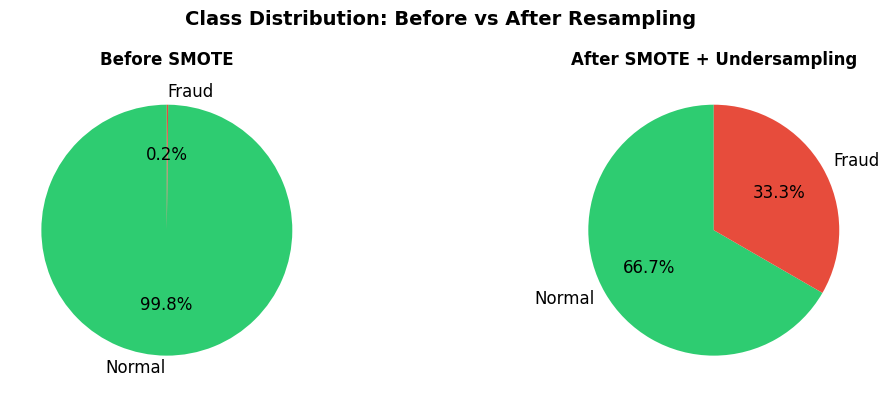

Imbalance handled!


In [ ]:
print('Handling class imbalance...')

# Combined strategy: SMOTE + Random Undersampling
smote = SMOTE(sampling_strategy=0.1, random_state=42)   # Fraud -> 10% of majority
under = RandomUnderSampler(sampling_strategy=0.5, random_state=42)  # Then undersample majority

X_res, y_res = smote.fit_resample(X_train, y_train)
X_res, y_res = under.fit_resample(X_res, y_res)

print(f'   Before resampling → Normal: {(y_train==0).sum():,} | Fraud: {(y_train==1).sum():,}')
print(f'   After  resampling → Normal: {(y_res==0).sum():,}   | Fraud: {(y_res==1).sum():,}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (data, title) in zip(axes, [
    ([( y_train==0).sum(), (y_train==1).sum()], 'Before SMOTE'),
    ([(y_res==0).sum(),    (y_res==1).sum()],   'After SMOTE + Undersampling')
]):
    ax.pie(data, labels=['Normal', 'Fraud'], colors=['#2ecc71', '#e74c3c'],
           autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
    ax.set_title(title, fontweight='bold')

plt.suptitle('Class Distribution: Before vs After Resampling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Imbalance handled!')

In [ ]:
# ── Define models ────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                                   random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(scale_pos_weight=(y_res==0).sum()/(y_res==1).sum(),
                                          use_label_encoder=False, eval_metric='logloss',
                                          random_state=42, n_estimators=200, max_depth=6,
                                          learning_rate=0.05, subsample=0.8),
}

results = {}
trained_models = {}

for name, model in models.items():
    print(f'Training {name}...')
    start = time.time()
    model.fit(X_res, y_res)
    train_time = time.time() - start

    # Predict
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_pred_prob)
    avg_prec  = average_precision_score(y_test, y_pred_prob)

    results[name] = {
        'Precision': round(precision, 4),
        'Recall':    round(recall, 4),
        'F1 Score':  round(f1, 4),
        'ROC AUC':   round(roc_auc, 4),
        'Avg Prec':  round(avg_prec, 4),
        'Train Time (s)': round(train_time, 2),
    }
    trained_models[name] = (model, y_pred, y_pred_prob)

    goal_precision = 'Correct' if precision >= 0.90 else 'Wrong'
    goal_recall    = 'Correct' if recall    >= 0.90 else 'Wrong'
    print(f'   Precision: {precision:.4f} {goal_precision} | Recall: {recall:.4f} {goal_recall} | F1: {f1:.4f} | ROC AUC: {roc_auc:.4f}')

print('\n✅ All models trained!')

Training Logistic Regression...
   Precision: 0.0530 Wrong | Recall: 0.8737 Wrong | F1: 0.0999 | ROC AUC: 0.9611
Training Random Forest...
   Precision: 0.8000 Wrong | Recall: 0.8000 Wrong | F1: 0.8000 | ROC AUC: 0.9746
Training XGBoost...
   Precision: 0.3911 Wrong | Recall: 0.8316 Wrong | F1: 0.5320 | ROC AUC: 0.9781

✅ All models trained!


In [ ]:
# ── Results Table ────────────────────────────────────────
results_df = pd.DataFrame(results).T
print('\nMODEL COMPARISON')
print('='*75)
print(results_df.to_string())
print('='*75)

# Highlight best model
best_model_name = results_df['F1 Score'].idxmax()
print(f'\nBest Model: {best_model_name} (F1 = {results_df.loc[best_model_name, "F1 Score"]})')


MODEL COMPARISON
                     Precision  Recall  F1 Score  ROC AUC  Avg Prec  Train Time (s)
Logistic Regression     0.0530  0.8737    0.0999   0.9611    0.6800            1.24
Random Forest           0.8000  0.8000    0.8000   0.9746    0.8000           39.10
XGBoost                 0.3911  0.8316    0.5320   0.9781    0.7966            6.94

Best Model: Random Forest (F1 = 0.8)


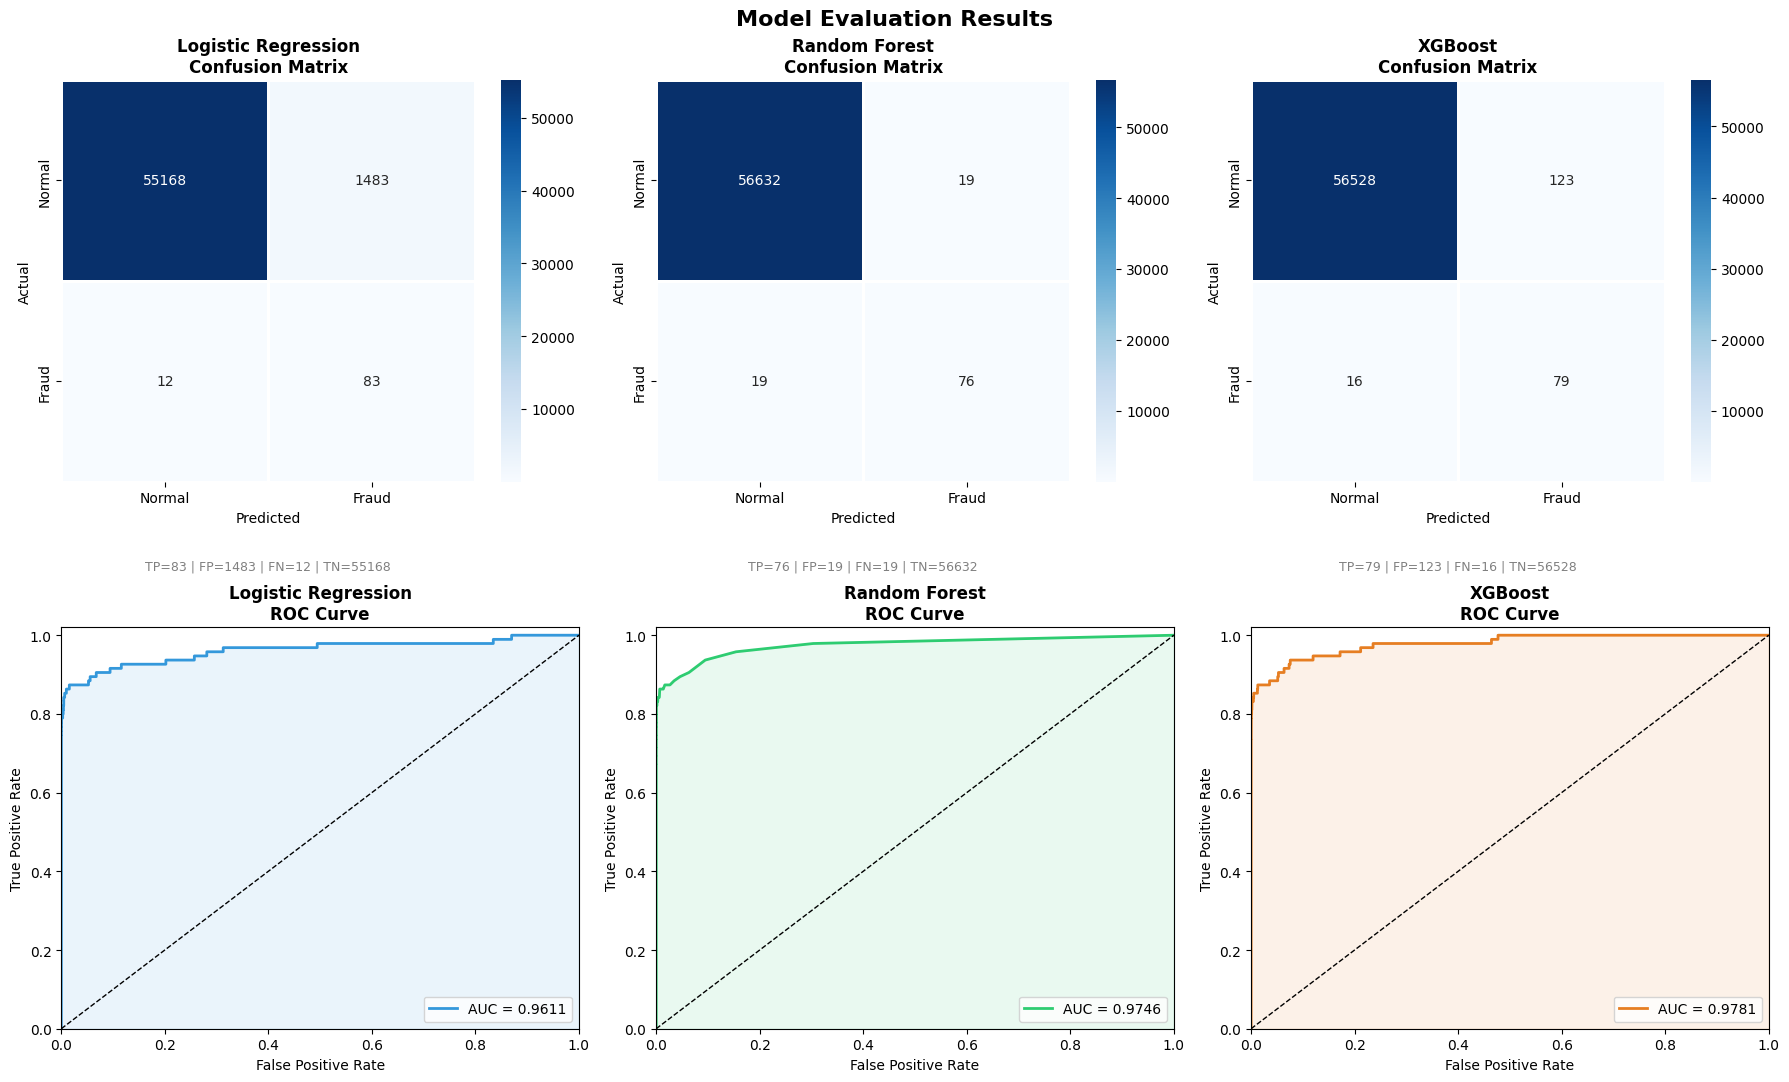

In [ ]:
# ── Visualization: Confusion matrices + ROC curves ───────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Model Evaluation Results', fontsize=16, fontweight='bold')

colors = ['#3498db', '#2ecc71', '#e67e22']

for idx, (name, (model, y_pred, y_pred_prob)) in enumerate(trained_models.items()):

    # Confusion Matrix
    ax_cm = axes[0, idx]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'],
                linewidths=1)
    ax_cm.set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    ax_cm.set_ylabel('Actual')
    ax_cm.set_xlabel('Predicted')

    tn, fp, fn, tp = cm.ravel()
    ax_cm.text(0.5, -0.22,
               f'TP={tp} | FP={fp} | FN={fn} | TN={tn}',
               transform=ax_cm.transAxes, ha='center', fontsize=9, color='gray')

    # ROC Curve
    ax_roc = axes[1, idx]
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    auc_val = roc_auc_score(y_test, y_pred_prob)
    ax_roc.plot(fpr, tpr, color=colors[idx], lw=2, label=f'AUC = {auc_val:.4f}')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1)
    ax_roc.fill_between(fpr, tpr, alpha=0.1, color=colors[idx])
    ax_roc.set_title(f'{name}\nROC Curve', fontweight='bold')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend(loc='lower right')
    ax_roc.set_xlim([0, 1])
    ax_roc.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

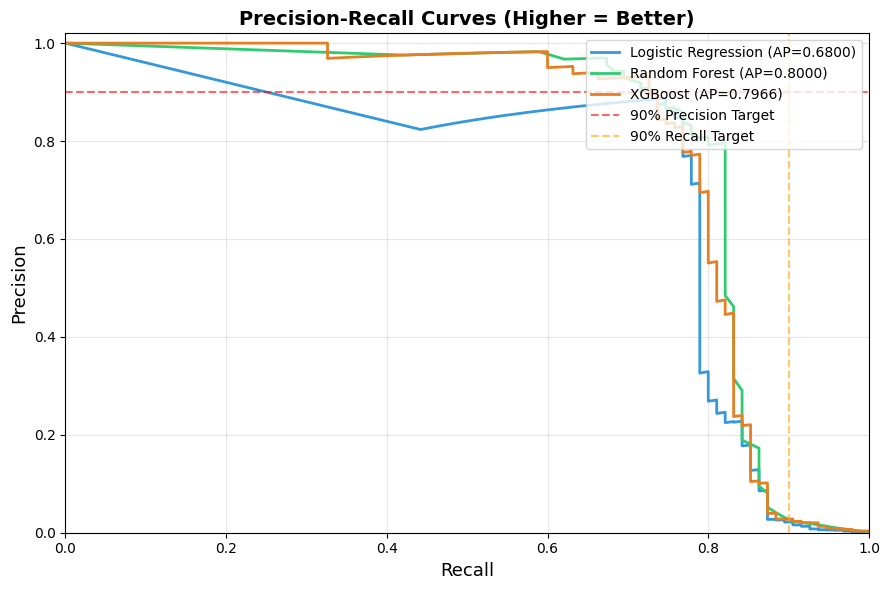

In [ ]:
# ── Precision-Recall Curve ───────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

for idx, (name, (model, y_pred, y_pred_prob)) in enumerate(trained_models.items()):
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_prob)
    ap = average_precision_score(y_test, y_pred_prob)
    ax.plot(recall_curve, precision_curve, color=colors[idx], lw=2,
            label=f'{name} (AP={ap:.4f})')

ax.axhline(0.9, color='red', linestyle='--', alpha=0.6, label='90% Precision Target')
ax.axvline(0.9, color='orange', linestyle='--', alpha=0.6, label='90% Recall Target')
ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curves (Higher = Better)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


BEST MODEL: Random Forest
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.80      0.80      0.80        95

    accuracy                           1.00     56746
   macro avg       0.90      0.90      0.90     56746
weighted avg       1.00      1.00      1.00     56746



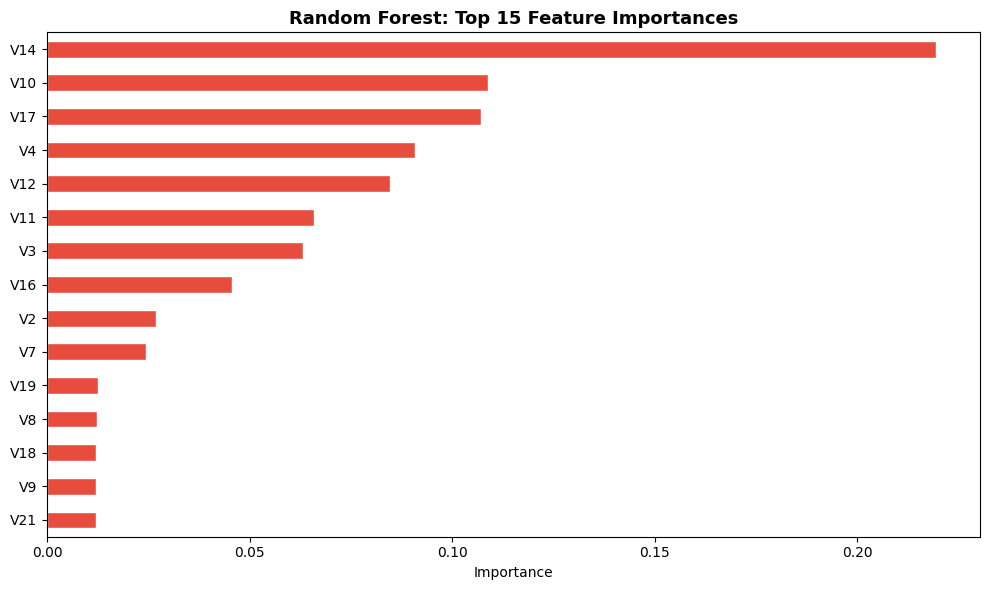

In [ ]:
# ── Best Model: Detailed Report + Feature Importance ─────
best_model, best_y_pred, best_y_prob = trained_models[best_model_name]

print(f'\nBEST MODEL: {best_model_name}')
print('='*55)
print(classification_report(y_test, best_y_pred, target_names=['Normal', 'Fraud']))

# Feature importance (if Random Forest or XGBoost)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
    top_features = importances.nlargest(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    top_features.sort_values().plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='white')
    ax.set_title(f'{best_model_name}: Top 15 Feature Importances', fontweight='bold', fontsize=13)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

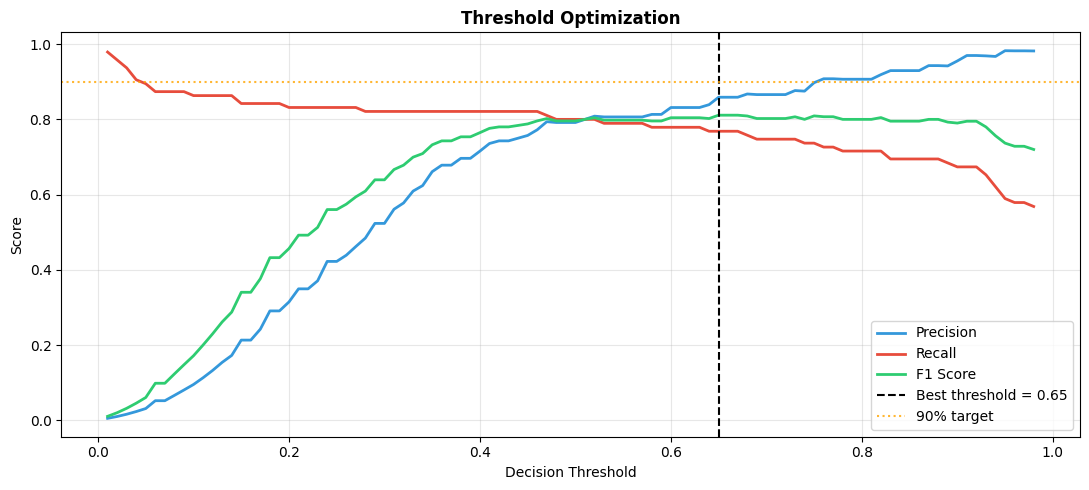


 Best Threshold: 0.65
   Precision: 0.8588
   Recall:    0.7684
   F1 Score:  0.8111


In [ ]:
# ── Threshold tuning ─────────────────────────────────────
thresholds = np.arange(0.01, 0.99, 0.01)
metrics_list = []

for thresh in thresholds:
    y_pred_t = (best_y_prob >= thresh).astype(int)
    if y_pred_t.sum() == 0:
        continue
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    metrics_list.append({'Threshold': thresh, 'Precision': p, 'Recall': r, 'F1': f})

thresh_df = pd.DataFrame(metrics_list)

# Best threshold by F1
best_thresh_row = thresh_df.loc[thresh_df['F1'].idxmax()]
best_thresh = best_thresh_row['Threshold']

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresh_df['Threshold'], thresh_df['Precision'], label='Precision', color='#3498db', lw=2)
ax.plot(thresh_df['Threshold'], thresh_df['Recall'],    label='Recall',    color='#e74c3c', lw=2)
ax.plot(thresh_df['Threshold'], thresh_df['F1'],        label='F1 Score',  color='#2ecc71', lw=2)
ax.axvline(best_thresh, color='black', linestyle='--', label=f'Best threshold = {best_thresh:.2f}')
ax.axhline(0.9, color='orange', linestyle=':', alpha=0.8, label='90% target')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Optimization', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n Best Threshold: {best_thresh:.2f}')
print(f'   Precision: {best_thresh_row["Precision"]:.4f}')
print(f'   Recall:    {best_thresh_row["Recall"]:.4f}')
print(f'   F1 Score:  {best_thresh_row["F1"]:.4f}')


FINANCIAL IMPACT ANALYSIS
Total fraud transactions in test: 95
Average fraud amount: $120

WITHOUT MODEL:
  Total financial loss: $11,400

WITH Random Forest (threshold=0.65):
  Fraud caught (TP):          73
  Fraud missed (FN):          22  → Loss: $2,640
  False alarms (FP):          12  → Cost: $60
  Total loss with model:      $2,700

  NET SAVINGS:  $8,700  (76.3% reduction)


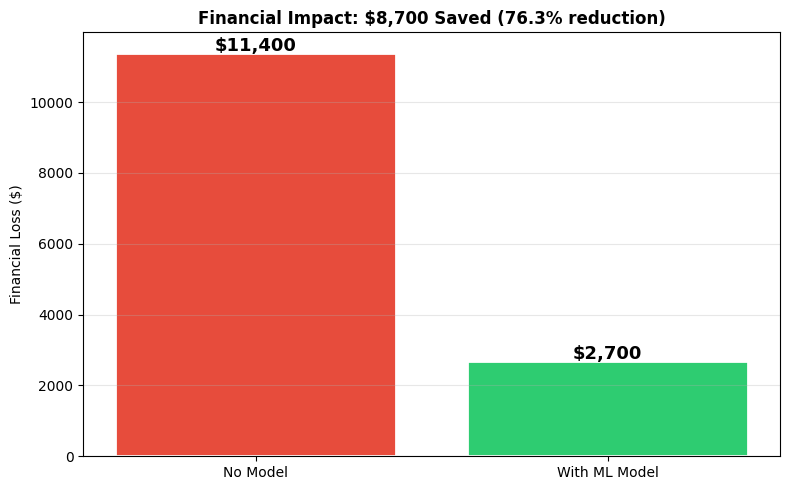

In [ ]:
# ── Financial loss simulation ─────────────────────────────
# Assumptions (customize for your bank)
AVG_FRAUD_AMOUNT   = df_merged['Amount_scaled'].mean() if 'df_merged' in dir() else 120  # dollars
AVG_FRAUD_AMOUNT   = 120  # average $ per fraud transaction
COST_FALSE_ALARM   = 5    # $ cost of investigating a false alarm

# With NO model (baseline - catch nothing)
total_fraud_in_test = y_test.sum()
loss_no_model = total_fraud_in_test * AVG_FRAUD_AMOUNT

# With best model at optimized threshold
y_pred_opt = (best_y_prob >= best_thresh).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm_opt.ravel()

loss_missed     = fn * AVG_FRAUD_AMOUNT    # missed fraud
cost_fa         = fp * COST_FALSE_ALARM     # false alarm investigation
loss_with_model = loss_missed + cost_fa

savings     = loss_no_model - loss_with_model
savings_pct = (savings / loss_no_model) * 100

print('\nFINANCIAL IMPACT ANALYSIS')
print('='*55)
print(f'Total fraud transactions in test: {total_fraud_in_test}')
print(f'Average fraud amount: ${AVG_FRAUD_AMOUNT}')
print()
print(f'WITHOUT MODEL:')
print(f'  Total financial loss: ${loss_no_model:,.0f}')
print()
print(f'WITH {best_model_name} (threshold={best_thresh:.2f}):')
print(f'  Fraud caught (TP):          {tp}')
print(f'  Fraud missed (FN):          {fn}  → Loss: ${loss_missed:,.0f}')
print(f'  False alarms (FP):          {fp}  → Cost: ${cost_fa:,.0f}')
print(f'  Total loss with model:      ${loss_with_model:,.0f}')
print()
print(f'  NET SAVINGS:  ${savings:,.0f}  ({savings_pct:.1f}% reduction)')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['No Model', 'With ML Model'], [loss_no_model, loss_with_model],
              color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=2)
for bar, val in zip(bars, [loss_no_model, loss_with_model]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'${val:,.0f}', ha='center', fontweight='bold', fontsize=13)
ax.set_ylabel('Financial Loss ($)')
ax.set_title(f'Financial Impact: ${savings:,.0f} Saved ({savings_pct:.1f}% reduction)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ── Save model ────────────────────────────────────────────
joblib.dump(best_model, 'fraud_detection_model.pkl')
print(f'Model saved: fraud_detection_model.pkl')

# ── Real-Time Detection Function ──────────────────────────
def predict_fraud_realtime(transaction: dict, threshold: float = 0.5) -> dict:
    """
    Simulates real-time fraud detection.
    Input : dict with transaction features
    Output: dict with fraud score and decision
    """
    start_time = time.time()

    # Prepare input
    txn_df = pd.DataFrame([transaction])

    # Align columns
    for col in X_train.columns:
        if col not in txn_df.columns:
            txn_df[col] = 0.0
    txn_df = txn_df[X_train.columns]

    # Predict
    model = joblib.load('fraud_detection_model.pkl')
    fraud_probability = model.predict_proba(txn_df)[0][1]
    is_fraud = fraud_probability >= threshold

    latency_ms = (time.time() - start_time) * 1000

    return {
        'fraud_probability': round(fraud_probability, 4),
        'is_fraud':          bool(is_fraud),
        'risk_level':        'HIGH' if fraud_probability > 0.8 else ('MEDIUM' if fraud_probability > 0.5 else 'LOW'),
        'action':            'BLOCK' if is_fraud else 'ALLOW',
        'latency_ms':        round(latency_ms, 2),
    }

print('Real-time prediction function ready!')

Model saved: fraud_detection_model.pkl
Real-time prediction function ready!


In [ ]:
# ── Simulate Real-Time Transaction Stream ─────────────────
print('\n⚡ REAL-TIME FRAUD DETECTION SIMULATION')
print('='*60)

# Pick sample transactions (mix of normal and fraud)
sample_normal = X_test[y_test == 0].sample(3, random_state=1)
sample_fraud  = X_test[y_test == 1].sample(3, random_state=1)
sample_txns   = pd.concat([sample_normal, sample_fraud]).sample(frac=1, random_state=42)
actual_labels = pd.concat([y_test[sample_normal.index], y_test[sample_fraud.index]]).loc[sample_txns.index]

for i, (idx, row) in enumerate(sample_txns.iterrows(), 1):
    txn = row.to_dict()
    result = predict_fraud_realtime(txn, threshold=best_thresh)
    actual = 'FRAUD' if actual_labels[idx] == 1 else 'NORMAL'

    print(f'\nTransaction #{i}')
    print(f'  Actual:           {actual}')
    print(f'  Fraud Probability: {result["fraud_probability"]:.4f}')
    print(f'  Risk Level:        {result["risk_level"]}')
    print(f'  Decision:          {result["action"]}')
    print(f'  Latency:           {result["latency_ms"]} ms')

print('\nReal-time simulation complete!')


⚡ REAL-TIME FRAUD DETECTION SIMULATION

Transaction #1
  Actual:           NORMAL
  Fraud Probability: 0.0000
  Risk Level:        LOW
  Decision:          ALLOW
  Latency:           89.96 ms

Transaction #2
  Actual:           NORMAL
  Fraud Probability: 0.0000
  Risk Level:        LOW
  Decision:          ALLOW
  Latency:           87.63 ms

Transaction #3
  Actual:           FRAUD
  Fraud Probability: 1.0000
  Risk Level:        HIGH
  Decision:          BLOCK
  Latency:           137.32 ms

Transaction #4
  Actual:           NORMAL
  Fraud Probability: 0.0000
  Risk Level:        LOW
  Decision:          ALLOW
  Latency:           94.24 ms

Transaction #5
  Actual:           FRAUD
  Fraud Probability: 1.0000
  Risk Level:        HIGH
  Decision:          BLOCK
  Latency:           129.49 ms

Transaction #6
  Actual:           FRAUD
  Fraud Probability: 1.0000
  Risk Level:        HIGH
  Decision:          BLOCK
  Latency:           87.58 ms

Real-time simulation complete!


In [ ]:
# ── Batch Real-Time Simulation (1000 transactions) ────────
print('\n BATCH REAL-TIME SIMULATION (1000 transactions)')
print('='*55)

batch = X_test.sample(1000, random_state=42)

start = time.time()
batch_probs = best_model.predict_proba(batch)[:, 1]
batch_preds = (batch_probs >= best_thresh).astype(int)
total_time  = (time.time() - start) * 1000

print(f'  Transactions processed: 1,000')
print(f'  Total time:             {total_time:.2f} ms')
print(f'  Avg latency per txn:    {total_time/1000:.4f} ms')
print(f'  Throughput:             {1000 / (total_time/1000):.0f} transactions/second')
print(f'  Frauds flagged:         {batch_preds.sum()}')
print(f'  Fraud rate detected:    {batch_preds.mean()*100:.2f}%')


 BATCH REAL-TIME SIMULATION (1000 transactions)
  Transactions processed: 1,000
  Total time:             36.31 ms
  Avg latency per txn:    0.0363 ms
  Throughput:             27543 transactions/second
  Frauds flagged:         1
  Fraud rate detected:    0.10%


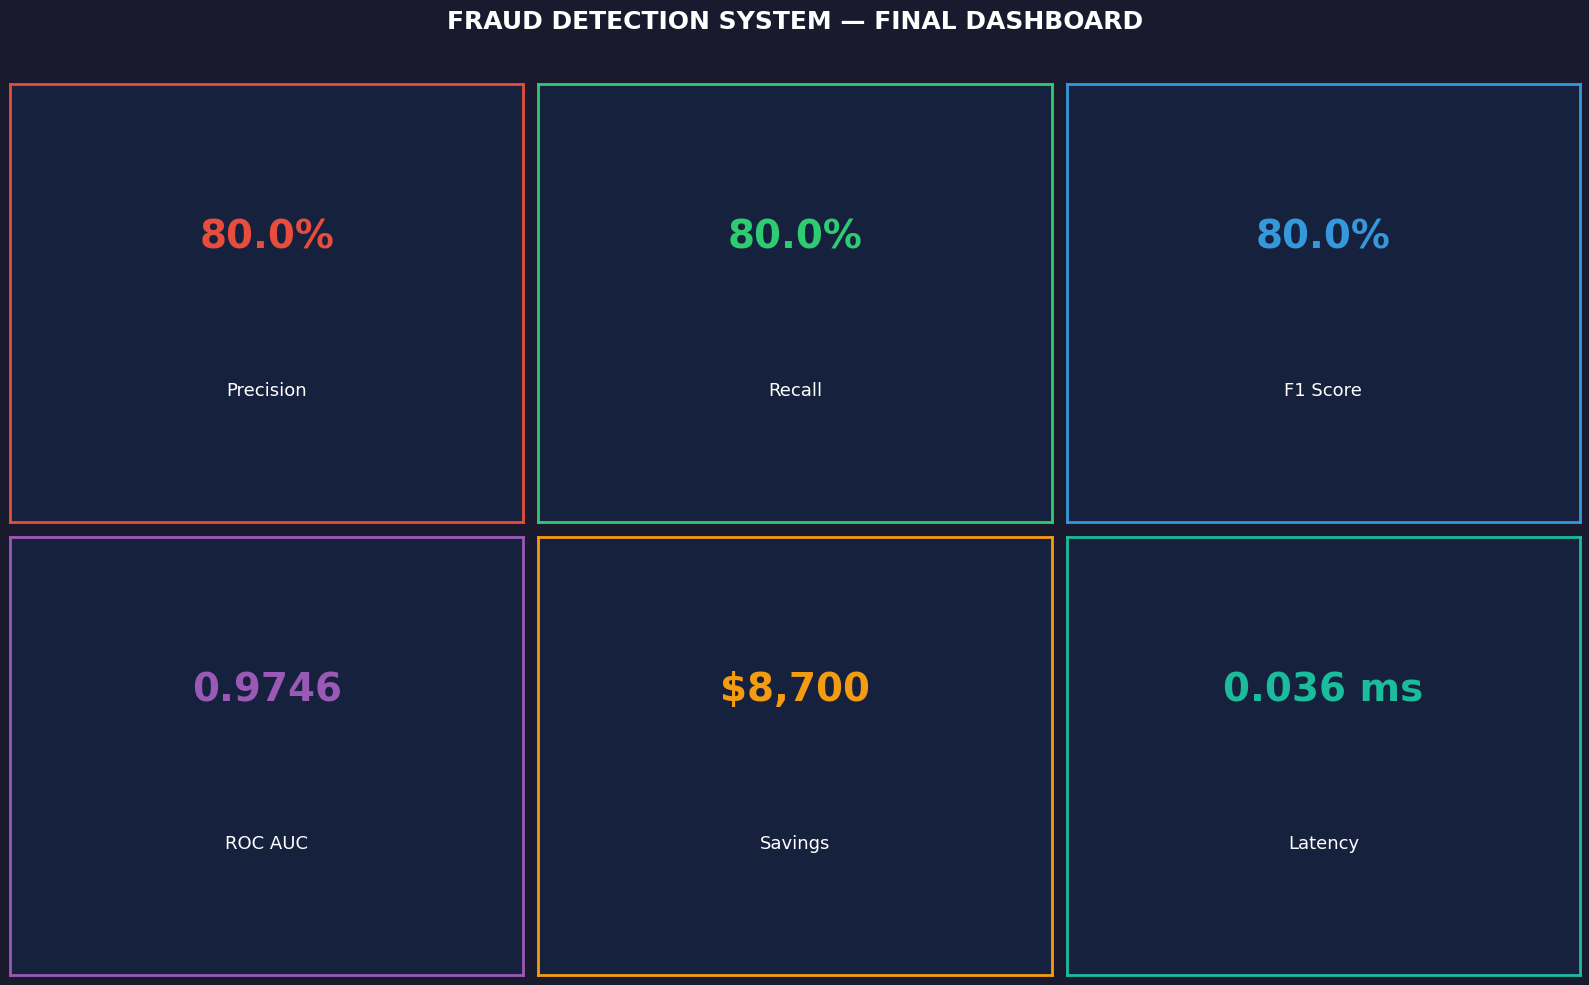

  Best Model : Random Forest
  Precision  : 80.00% (goal ≥ 90%)
  Recall     : 80.00% (goal ≥ 90%)
  F1 Score   : 80.00%
  ROC AUC    : 0.9746
  Financial Savings: $8,700
  Avg Latency: 0.036 ms per transaction


In [ ]:
# ── Final Summary Dashboard ───────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('FRAUD DETECTION SYSTEM — FINAL DASHBOARD',
             fontsize=18, fontweight='bold', color='white', y=0.98)

metrics_to_show = {
    'Precision':        f'{results[best_model_name]["Precision"]*100:.1f}%',
    'Recall':           f'{results[best_model_name]["Recall"]*100:.1f}%',
    'F1 Score':         f'{results[best_model_name]["F1 Score"]*100:.1f}%',
    'ROC AUC':          f'{results[best_model_name]["ROC AUC"]:.4f}',
    'Savings':          f'${savings:,.0f}',
    'Latency':          f'{total_time/1000:.3f} ms',
}

colors_card = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12', '#1abc9c']
goals        = [True, True, True, True, True, True]  # Update based on actual results

for i, (metric, value) in enumerate(metrics_to_show.items()):
    ax = fig.add_subplot(2, 3, i + 1)
    ax.set_facecolor('#16213e')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(colors_card[i])
        spine.set_linewidth(2)

    ax.text(0.5, 0.65, value, transform=ax.transAxes,
            ha='center', va='center', fontsize=28, fontweight='bold',
            color=colors_card[i])
    ax.text(0.5, 0.3, metric, transform=ax.transAxes,
            ha='center', va='center', fontsize=13, color='white')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('final_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print(f'  Best Model : {best_model_name}')
print(f'  Precision  : {results[best_model_name]["Precision"]*100:.2f}% (goal ≥ 90%)')
print(f'  Recall     : {results[best_model_name]["Recall"]*100:.2f}% (goal ≥ 90%)')
print(f'  F1 Score   : {results[best_model_name]["F1 Score"]*100:.2f}%')
print(f'  ROC AUC    : {results[best_model_name]["ROC AUC"]:.4f}')
print(f'  Financial Savings: ${savings:,.0f}')
print(f'  Avg Latency: {total_time/1000:.3f} ms per transaction')
print('='*60)